# Reviewer 1 — ancestry reclassification: EUR / non-EUR / mixed

**Comment.** The original definition (Methods) was binary: `EUR` = predominant ancestry
$\geq 90\%$ non-Finnish European (NFE), `non-EUR` = everything else. Under that rule an
89%-European pan-ancestry meta-analysis is labelled "non-EUR", and so is FinnGen. The
headline claim — *~30% of disease-associated genes were first found in non-EUR studies* —
is therefore compatible with the growth being driven entirely by larger European
meta-analyses. The reviewer proposes the remedy used here.

**New classification (three ancestry labels + orthogonal frequency label).**

| Label     | Rule                                                                                  |
| --------- | ------------------------------------------------------------------------------------- |
| `EUR`     | one ancestry reaches $\geq 90\%$ of the sample **and** it is non-Finnish European      |
| `non-EUR` | one ancestry reaches $\geq 90\%$ and it is **not** NFE (so Finnish counts as non-EUR)  |
| `mixed`   | no single ancestry reaches $90\%$ (pan-ancestry meta-analyses land here)               |
| `rare`    | MAF $< 0.01$; reported separately, orthogonal to ancestry (unchanged)                  |

**Studies with unusable ancestry metadata are called `EUR`.** 31 of 100,526 GWAS (0.03%) have no
determinable predominant ancestry: 17 have a null or empty `ldPopulationStructure`, 13 list a
single population (all `nfe`) with a null `relativeSampleSize`, and 1 lists four populations with
all sizes null. Defaulting them to `EUR` is the conservative choice — it can only shrink the
non-EUR and mixed contributions, never inflate them — and at 0.03% of studies it cannot move any
reported number. The `ldStructureNote` column flags exactly which studies were defaulted, so the
decision stays auditable.

**What this notebook computes.**

1. Reclassifies every GWAS study in the 25.06 study index into the three ancestry labels, and
   cross-tabulates against the old binary `is_nfe` flag.
2. Rebuilds the row-level gene-discovery table (`list_of_prioritised_genes_per_CS_*`) carrying
   the new labels.
3. Recomputes, per category and per year (2006–2024):
   - unique disease-associated genes first discovered,
   - total (unique) gene–disease associations,
   - the year-by-year first-discovery curve underlying **Figure 1c**,
   - the same quantities for measurements, underlying **Extended Data Figure 3**.
4. Writes replot inputs and summary tables to `data/intermediate_files/` with a `-r1` suffix.
   **No figure script is touched** — replotting happens later in `chapters/03-manuscript-figures/`.

**Reference implementations this notebook reproduces (with the new labels):**

- `chapters/01-data-preparation/06_l2g_predictions.ipynb` (built the original `is_nfe` flag)
- `chapters/02-analysis/01-descriptions-numbers/01_descriptive_numbers.ipynb` (study-level ancestry counts)
- `chapters/02-analysis/01-descriptions-numbers/02_gene_stauration_plots.ipynb` (cumulative discovery curves)
- `chapters/03-manuscript-figures/figure_1/Figure_1_b_c.R` (Figure 1c layering)
- `chapters/03-manuscript-figures/extended_figures/ed3_temporal_measurement_genes.ipynb` (ED Fig 3)

## Setup

In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from pyspark.sql import DataFrame
from pyspark.sql import functions as f

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/10 16:01:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

# Analysis constants. Kept identical to the original analysis except for the ancestry rule.
ANCESTRY_THRESHOLD = 0.9  # relative sample size a single ancestry must reach to be "predominant"
MAF_COMMON = 0.01  # MAF >= this is "common"; below is "rare"
MAX_YEAR = 2024  # 2025 is a partial year and was excluded in the original figures
SUFFIX = "-r1"  # appended to every output file so nothing overwrites the original analysis

# Order in which ancestry labels are added to the nested (stacked) tiers of Fig 1c / ED Fig 3:
# 1) EUR common, 2) non-EUR common, 3) mixed common, 4) rare (any ancestry).
ANCESTRY_ORDER = ["EUR", "non-EUR", "mixed"]

ANCESTRY_COLORS = {"EUR": "#4472C4", "non-EUR": "#70AD47", "mixed": "#ED7D31", "rare": "#FFC000"}

## Load inputs

In [4]:
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

# Gene prioritisation per credible set (L2G-based), as produced by 06_l2g_predictions.ipynb.
l2g_prioritised = session.spark.read.parquet(
    path_to_intermediate_data_folder + "list_of_prioritised_genes_per_CS.parquet"
)

# Lead variant effect table: source of MAF (major LD population) and variantId.
sl_eff = session.spark.read.parquet(path_to_intermediate_data_folder + "lead_variant_effect")

# Qualifying credible sets: diseases and measurements.
qd_cs = (
    session.spark.read.parquet(path_to_intermediate_data_folder + "qualifying_credible_sets")
    .select("studyLocusId")
    .distinct()
    .cache()
)
qm_cs = (
    session.spark.read.parquet(path_to_intermediate_data_folder + "qualifying_measurement_credible_sets")
    .select("studyLocusId")
    .distinct()
    .cache()
)
print(f"qualifying disease CSs:     {qd_cs.count():,}")
print(f"qualifying measurement CSs: {qm_cs.count():,}")

qualifying disease CSs:     70,618


qualifying measurement CSs: 450,357


## 1. Reclassify studies

`ldPopulationStructure` is an array of `{ldPopulation, relativeSampleSize}`. Gentropy uses five
LD population labels: `nfe`, `fin`, `afr`, `amr`, `eas` (see
`src/manuscript_methods/ld_populations.py`). The predominant ancestry is the element with the
largest `relativeSampleSize`; `array_max` over a `struct(frac, pop)` gives it directly because
Spark compares structs field by field.

In [5]:
def classify_ancestry(df: DataFrame, threshold: float = ANCESTRY_THRESHOLD) -> DataFrame:
    """Add ancestry classification columns derived from `ldPopulationStructure`.

    Adds:
        nLdPopulations: number of LD populations reported for the study (0 if none).
        predominantAncestry: LD population with the largest relative sample size.
        predominantFraction: that largest relative sample size, after repair (see below).
        nfeFraction: relative sample size of the `nfe` population (0 if absent).
        ldStructureNote: `defined`, `single_population_imputed` (one population listed with a
            null relative sample size -- imputed to 1.0, since every one of the 85,851
            single-population studies with a non-null value reports exactly 1.0),
            `undefined_relative_sample_size` (several populations, all sizes null), or
            `empty_ld` (structure null or empty).
        ancestryClass: one of EUR / non-EUR / mixed. Studies whose predominant ancestry cannot
            be determined (`undefined_relative_sample_size`, `empty_ld`) default to EUR: that is
            conservative, since it can only shrink the non-EUR and mixed contributions.

    Args:
        df: study index dataframe containing `ldPopulationStructure`.
        threshold: relative sample size a single ancestry must reach to be predominant.

    Returns:
        DataFrame: the input with the columns above appended.
    """
    pops = f.col("ldPopulationStructure")

    # struct(frac, pop) so that array_max picks the element with the largest relative sample size
    top = f.array_max(
        f.transform(
            pops,
            lambda x: f.struct(
                x["relativeSampleSize"].alias("frac"),
                x["ldPopulation"].alias("pop"),
            ),
        )
    )

    # Total relative sample size attributed to non-Finnish Europeans (continuous version).
    nfe_fraction = f.coalesce(
        f.aggregate(
            f.transform(
                f.filter(pops, lambda x: x["ldPopulation"] == f.lit("nfe")),
                lambda x: f.coalesce(x["relativeSampleSize"], f.lit(0.0)),
            ),
            f.lit(0.0),
            lambda acc, x: acc + x,
        ),
        f.lit(0.0),
    )

    return (
        # f.size() returns -1 for a null array under gentropy's session conf, hence the isNull guard.
        df.withColumn("nLdPopulations", f.when(pops.isNull(), f.lit(0)).otherwise(f.size(pops)))
        .withColumn("predominantAncestry", top["pop"])
        .withColumn("rawPredominantFraction", top["frac"])
        .withColumn("nfeFraction", nfe_fraction)
        .withColumn(
            "ldStructureNote",
            f.when(f.col("nLdPopulations") == 0, f.lit("empty_ld"))
            .when(f.col("rawPredominantFraction").isNotNull(), f.lit("defined"))
            .when(f.col("nLdPopulations") == 1, f.lit("single_population_imputed"))
            .otherwise(f.lit("undefined_relative_sample_size")),
        )
        # A single listed population is the whole sample, so a null size means 1.0.
        .withColumn(
            "predominantFraction",
            f.when(f.col("ldStructureNote") == "single_population_imputed", f.lit(1.0)).otherwise(
                f.col("rawPredominantFraction")
            ),
        )
        .drop("rawPredominantFraction")
        .withColumn(
            "ancestryClass",
            # Undeterminable ancestry defaults to EUR (conservative, 0.03% of studies).
            f.when(f.col("predominantFraction").isNull(), f.lit("EUR"))
            .when(f.col("predominantFraction") < f.lit(threshold), f.lit("mixed"))
            .when(f.col("predominantAncestry") == f.lit("nfe"), f.lit("EUR"))
            .otherwise(f.lit("non-EUR")),
        )
    )

In [6]:
# FinnGen R12 has no publication date in the release; the original analysis pins it to the
# R12 release date. Keep that, so years are comparable with the published figures.
si_ann = (
    si.df.filter(f.col("studyType") == "gwas")
    .withColumn(
        "publicationDate",
        f.when(f.col("projectId") == "FINNGEN_R12", f.lit("2024-11-04")).otherwise(f.col("publicationDate")),
    )
    .withColumn("year", f.col("publicationDate").substr(1, 4).cast("int"))
    .transform(classify_ancestry)
    # Old binary flag, reproduced verbatim from 06_l2g_predictions.ipynb, for direct comparison.
    .withColumn(
        "is_nfe_old",
        f.when(
            f.size(
                f.filter(
                    f.col("ldPopulationStructure"),
                    lambda x: (x["ldPopulation"] == "nfe") & (x["relativeSampleSize"] >= ANCESTRY_THRESHOLD),
                )
            )
            > 0,
            1,
        ).otherwise(0),
    )
    .cache()
)
print(f"GWAS studies: {si_ann.count():,}")

26/08/10 16:01:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


GWAS studies: 100,526


In [7]:
# Sanity check. The new EUR label must equal the old is_nfe == 1 set, plus exactly the studies
# whose ancestry could not be determined and were therefore defaulted to EUR.
si_ann.groupBy("ancestryClass", "is_nfe_old").count().orderBy("ancestryClass", "is_nfe_old").show()
si_ann.groupBy("ldStructureNote", "ancestryClass").count().orderBy("ldStructureNote", "ancestryClass").show()

defaulted = si_ann.filter((f.col("ancestryClass") == "EUR") & (f.col("is_nfe_old") == 0))
print(f"studies called EUR that the old rule did not: {defaulted.count()}")
defaulted.groupBy("ldStructureNote", "nLdPopulations", "predominantAncestry").count().show()

# No study the old rule called European may end up outside EUR.
assert si_ann.filter((f.col("ancestryClass") != "EUR") & (f.col("is_nfe_old") == 1)).count() == 0

+-------------+----------+-----+
|ancestryClass|is_nfe_old|count|
+-------------+----------+-----+
|          EUR|         0|   31|
|          EUR|         1|65222|
|        mixed|         0|11725|
|      non-EUR|         0|23548|
+-------------+----------+-----+

+--------------------+-------------+-----+
|     ldStructureNote|ancestryClass|count|
+--------------------+-------------+-----+
|             defined|          EUR|65222|
|             defined|        mixed|11725|
|             defined|      non-EUR|23548|
|            empty_ld|          EUR|   17|
|single_population...|          EUR|   13|
|undefined_relativ...|          EUR|    1|
+--------------------+-------------+-----+



studies called EUR that the old rule did not: 31
+--------------------+--------------+-------------------+-----+
|     ldStructureNote|nLdPopulations|predominantAncestry|count|
+--------------------+--------------+-------------------+-----+
|            empty_ld|             0|               NULL|   17|
|single_population...|             1|                nfe|   13|
|undefined_relativ...|             4|                nfe|    1|
+--------------------+--------------+-------------------+-----+



In [8]:
# What the old "non-EUR" bucket actually contained.
si_ann.groupBy("ancestryClass", "predominantAncestry").count().orderBy("ancestryClass", f.desc("count")).show(50)

+-------------+-------------------+-----+
|ancestryClass|predominantAncestry|count|
+-------------+-------------------+-----+
|          EUR|                nfe|65236|
|          EUR|               NULL|   17|
|        mixed|                nfe| 9701|
|        mixed|                eas| 1795|
|        mixed|                afr|  119|
|        mixed|                amr|  110|
|      non-EUR|                eas|11785|
|      non-EUR|                afr| 7421|
|      non-EUR|                fin| 2303|
|      non-EUR|                amr| 2039|
+-------------+-------------------+-----+



In [9]:
# Study-level counts, mirroring 01_descriptive_numbers.ipynb.
studies_with_cs = (
    session.spark.read.parquet(path_to_release_folder + "output/credible_set").select("studyId").distinct().cache()
)
print(f"studies with credible sets: {studies_with_cs.count():,}")


def study_counts(df: DataFrame, label: str) -> pd.DataFrame:
    """Count studies per ancestry class and express them as percentages.

    Args:
        df: study-level dataframe carrying `ancestryClass`.
        label: name of the study subset, stored in the `subset` column.

    Returns:
        pandas.DataFrame: one row per ancestry class with counts and percentages.
    """
    out = df.groupBy("ancestryClass").count().toPandas().sort_values("ancestryClass").reset_index(drop=True)
    out["subset"] = label
    out["pct"] = 100 * out["count"] / out["count"].sum()
    return out[["subset", "ancestryClass", "count", "pct"]]


study_summary = pd.concat(
    [
        study_counts(si_ann, "all GWAS"),
        study_counts(si_ann.join(studies_with_cs, "studyId", "inner"), "GWAS with CSs"),
        study_counts(si_ann.filter(f.col("year") <= 2017), "all GWAS, year <= 2017"),
        study_counts(si_ann.filter(f.col("year") >= 2018), "all GWAS, year >= 2018"),
    ],
    ignore_index=True,
)
study_summary

studies with credible sets: 1,864,151


,subset,ancestryClass,count,pct
0,all GWAS,EUR,65253,64.911565
1,all GWAS,mixed,11725,11.663649
2,all GWAS,non-EUR,23548,23.424786
3,GWAS with CSs,EUR,26736,68.061708
4,GWAS with CSs,mixed,5393,13.728934
5,GWAS with CSs,non-EUR,7153,18.209358
6,"all GWAS, year <= 2017",EUR,6309,76.920263
7,"all GWAS, year <= 2017",mixed,620,7.559132
8,"all GWAS, year <= 2017",non-EUR,1273,15.520605
9,"all GWAS, year >= 2018",EUR,58944,63.844721


In [10]:
# Persist the per-study classification: this is the lookup any other R1 analysis should reuse.
study_ancestry = si_ann.select(
    "studyId",
    "projectId",
    "studyType",
    "traitFromSource",
    "year",
    "nSamples",
    "nLdPopulations",
    "ldStructureNote",
    "predominantAncestry",
    "predominantFraction",
    "nfeFraction",
    "ancestryClass",
    "is_nfe_old",
).toPandas()

study_ancestry_path = f"{path_to_intermediate_data_folder}study_ancestry_classification{SUFFIX}.csv"
study_ancestry.to_csv(study_ancestry_path, index=False)
print(f"wrote {study_ancestry_path}  ({len(study_ancestry):,} rows)")
study_ancestry.head(3)

wrote ../../../data/intermediate_files/study_ancestry_classification-r1.csv  (100,526 rows)


,studyId,projectId,studyType,traitFromSource,year,nSamples,nLdPopulations,ldStructureNote,predominantAncestry,predominantFraction,nfeFraction,ancestryClass,is_nfe_old
0,FINNGEN_R12_AUTOIMMUNE_HYPERTHYROIDISM,FINNGEN_R12,gwas,Autoimmune hyperthyroidism,2024,373106.0,1,defined,fin,1.0,0.0,non-EUR,0
1,FINNGEN_R12_CD2_BENIGN_LARYNX,FINNGEN_R12,gwas,Benign neoplasm: Larynx,2024,500348.0,1,defined,fin,1.0,0.0,non-EUR,0
2,FINNGEN_R12_E4_ADRENAS,FINNGEN_R12,gwas,"Disorders of adrenal gland, other and/or unspe...",2024,479236.0,1,defined,fin,1.0,0.0,non-EUR,0


### What the old `non-EUR` bucket was made of

Two things the reviewer's concern hinges on:

1. how much of the new `non-EUR` class is Finnish (which the old rule swept in), and
2. whether `mixed` really is the "large European meta-analysis" bucket — quantified by
   `nfeFraction`, the share of the sample that is non-Finnish European.

In [11]:
noneur_composition = (
    study_ancestry[study_ancestry["ancestryClass"] == "non-EUR"]["predominantAncestry"]
    .value_counts()
    .rename_axis("predominantAncestry")
    .reset_index(name="n_studies")
)
noneur_composition["pct_within_class"] = 100 * noneur_composition["n_studies"] / noneur_composition["n_studies"].sum()
noneur_composition["ancestryClass"] = "non-EUR"
print("Composition of the new non-EUR class:")
print(noneur_composition.to_string(index=False))

mixed = study_ancestry[study_ancestry["ancestryClass"] == "mixed"]
print()
print("nfeFraction within mixed studies:")
print(mixed["nfeFraction"].describe().to_string())
for cut in [0.5, 0.7, 0.8]:
    n = int((mixed["nfeFraction"] > cut).sum())
    print(f"  mixed studies with nfeFraction > {cut}: {n:,} ({100 * n / len(mixed):.1f}% of mixed)")

mixed_composition = (
    mixed["predominantAncestry"].value_counts().rename_axis("predominantAncestry").reset_index(name="n_studies")
)
mixed_composition["pct_within_class"] = 100 * mixed_composition["n_studies"] / mixed_composition["n_studies"].sum()
mixed_composition["ancestryClass"] = "mixed"

ancestry_composition = pd.concat([noneur_composition, mixed_composition], ignore_index=True)[
    ["ancestryClass", "predominantAncestry", "n_studies", "pct_within_class"]
]
ancestry_composition

Composition of the new non-EUR class:
predominantAncestry  n_studies  pct_within_class ancestryClass
                eas      11785         50.046713       non-EUR
                afr       7421         31.514354       non-EUR
                fin       2303          9.780024       non-EUR
                amr       2039          8.658909       non-EUR

nfeFraction within mixed studies:
count    11725.000000
mean         0.625052
std          0.226943
min          0.000000
25%          0.333333
50%          0.713223
75%          0.824785
max          0.899923
  mixed studies with nfeFraction > 0.5: 7,479 (63.8% of mixed)
  mixed studies with nfeFraction > 0.7: 6,728 (57.4% of mixed)
  mixed studies with nfeFraction > 0.8: 4,535 (38.7% of mixed)


,ancestryClass,predominantAncestry,n_studies,pct_within_class
0,non-EUR,eas,11785,50.046713
1,non-EUR,afr,7421,31.514354
2,non-EUR,fin,2303,9.780024
3,non-EUR,amr,2039,8.658909
4,mixed,nfe,9701,82.737740
5,mixed,eas,1795,15.309168
6,mixed,afr,119,1.014925
7,mixed,amr,110,0.938166


## 2. Rebuild the row-level gene-discovery table

Same construction as `06_l2g_predictions.ipynb`: prioritised genes per credible set, joined to
the lead-variant MAF and to the study year. The old flags (`nfe_common`, `non_nfe_common`,
`rare`) are kept unchanged so the new file is a drop-in superset of the original; the new
four-way flags are added alongside.

In [12]:
sl_eff_slim = sl_eff.select(
    "studyId",
    "studyLocusId",
    "variantId",
    f.abs(f.col("rescaledStatistics.absEstimatedBeta")).alias("absBeta"),
    f.col("majorLdPopulationMaf.value").alias("maf"),
)

si_slim = si_ann.select(
    "studyId",
    "projectId",
    "year",
    "nSamples",
    "diseaseIds",
    "ancestryClass",
    "predominantAncestry",
    "predominantFraction",
    "nfeFraction",
    "is_nfe_old",
)

l2g_full = (
    l2g_prioritised.join(sl_eff_slim, on="studyLocusId", how="inner")
    .join(si_slim, on="studyId", how="inner")
    # Null MAF was treated as 0 (i.e. rare) in the original analysis; keep that.
    .fillna({"maf": 0})
    .withColumn("freqClass", f.when(f.col("maf") >= MAF_COMMON, f.lit("common")).otherwise(f.lit("rare")))
    # --- old binary flags, verbatim ---
    .withColumn("is_nfe", f.col("is_nfe_old"))
    .withColumn("nfe_common", f.when((f.col("is_nfe_old") == 1) & (f.col("maf") >= MAF_COMMON), 1).otherwise(0))
    .withColumn("non_nfe_common", f.when((f.col("is_nfe_old") == 0) & (f.col("maf") >= MAF_COMMON), 1).otherwise(0))
    .withColumn("rare", f.when(f.col("maf") < MAF_COMMON, 1).otherwise(0))
    # --- new four-way flags ---
    .withColumn(
        "eur_common", f.when((f.col("ancestryClass") == "EUR") & (f.col("freqClass") == "common"), 1).otherwise(0)
    )
    .withColumn(
        "mixed_common", f.when((f.col("ancestryClass") == "mixed") & (f.col("freqClass") == "common"), 1).otherwise(0)
    )
    .withColumn(
        "noneur_common",
        f.when((f.col("ancestryClass") == "non-EUR") & (f.col("freqClass") == "common"), 1).otherwise(0),
    )
    .cache()
)
print(f"gene x credible-set rows: {l2g_full.count():,}")

gene x credible-set rows: 788,767


In [13]:
l2g_full_path = f"{path_to_intermediate_data_folder}list_of_prioritised_genes_per_CS_with_year_ancestry{SUFFIX}.parquet"
l2g_full.write.mode("overwrite").parquet(l2g_full_path)
print(f"wrote {l2g_full_path}")

wrote ../../../data/intermediate_files/list_of_prioritised_genes_per_CS_with_year_ancestry-r1.parquet


In [14]:
# Disease and measurement subsets, matching 02_gene_stauration_plots.ipynb / ED Fig 3.
l2g_diseases_full = l2g_full.join(qd_cs, on="studyLocusId", how="inner").toPandas()
l2g_measurements_full = l2g_full.join(qm_cs, on="studyLocusId", how="inner").toPandas()

print(f"disease gene-CS rows:     {len(l2g_diseases_full):,}")
print(f"measurement gene-CS rows: {len(l2g_measurements_full):,}")
l2g_diseases_full.head(2)

disease gene-CS rows:     70,400
measurement gene-CS rows: 453,009


,studyLocusId,studyId,geneId,score,eQTL_coloc,pQTL_coloc,VEP,distanceTSS,variantId,absBeta,...,nfeFraction,is_nfe_old,freqClass,is_nfe,nfe_common,non_nfe_common,rare,eur_common,mixed_common,noneur_common
0,30cce95d326cb3f229b5eda31646a299,FINNGEN_R12_AUTOIMMUNE_HYPERTHYROIDISM,ENSG00000160185,0.906458,1,0,0,1,21_42434957_A_C,0.178914,...,0.0,0,common,0,0,1,0,0,0,1
1,75f85c446bff166de1086225a3b66bd8,FINNGEN_R12_AUTOIMMUNE_HYPERTHYROIDISM,ENSG00000134242,0.853254,0,0,1,0,1_113761186_C_A,0.413421,...,0.0,0,common,0,0,1,0,0,0,1


In [15]:
# Replot inputs. Column layout is a superset of the originals
# (figure_1/l2g_diseases_full.csv), so existing scripts keep working unchanged.
diseases_csv = f"{path_to_intermediate_data_folder}l2g_diseases_full{SUFFIX}.csv"
measurements_csv = f"{path_to_intermediate_data_folder}l2g_measurements_full{SUFFIX}.csv"

l2g_diseases_full.to_csv(diseases_csv, index=False)
l2g_measurements_full.to_csv(measurements_csv, index=False)
print(f"wrote {diseases_csv}")
print(f"wrote {measurements_csv}")

wrote ../../../data/intermediate_files/l2g_diseases_full-r1.csv
wrote ../../../data/intermediate_files/l2g_measurements_full-r1.csv


## 3. Discovery statistics

Three views of the same data:

- **Nested tiers** — what the stacked bars of Fig 1c / ED Fig 3 actually encode. Tier $k$ is the
  set of genes (or pairs) discoverable using only studies in the first $k$ ancestry labels,
  restricted to common variants; the last tier adds rare variants from any ancestry. The plotted
  layer heights are the increments between consecutive tiers.
- **Marginal** — genes/pairs discovered *within* a single ancestry × frequency stratum,
  independent of every other stratum. Strata overlap.
- **Exclusive / attribution** — for each gene, which strata it is reachable from, and the stratum
  of its earliest discovery. This is what answers the reviewer directly: how many genes would
  *not* exist without strictly non-European studies.

In [16]:
def first_discovery(df: pd.DataFrame, id_cols: list[str], mask: pd.Series | None = None) -> pd.DataFrame:
    """First year each unique entity (gene, or gene-trait pair) appears.

    Args:
        df: row-level discovery table.
        id_cols: columns identifying the entity.
        mask: optional boolean mask restricting the rows considered.

    Returns:
        pandas.DataFrame: one row per entity with its first year of discovery.
    """
    sub = df if mask is None else df[mask]
    sub = sub[id_cols + ["year"]].dropna(subset=["year"])
    sub = sub[sub["year"] <= MAX_YEAR].drop_duplicates()
    return sub.groupby(id_cols, as_index=False)["year"].min()


def cumulative_curve(first: pd.DataFrame, years: list[int]) -> pd.DataFrame:
    """Per-year new discoveries and their cumulative sum over a fixed year axis.

    Args:
        first: output of `first_discovery`.
        years: year axis to reindex onto.

    Returns:
        pandas.DataFrame: columns `year`, `count`, `cumulative`.
    """
    per_year = first.groupby("year").size().reindex(years, fill_value=0).rename("count").reset_index()
    per_year = per_year.rename(columns={"index": "year"})
    per_year["cumulative"] = per_year["count"].cumsum()
    return per_year


def explode_pairs(df: pd.DataFrame, trait_col: str = "diseaseIds") -> pd.DataFrame:
    """Explode the trait-id array column so each row is one gene-trait pair.

    Args:
        df: row-level discovery table with an array-valued trait column.
        trait_col: name of the array column to explode.

    Returns:
        pandas.DataFrame: exploded copy with a scalar `traitId` column.
    """
    out = df.explode(trait_col).rename(columns={trait_col: "traitId"})
    return out[out["traitId"].notna()].copy()

In [17]:
def nested_tiers(df: pd.DataFrame, id_cols: list[str], metric: str) -> pd.DataFrame:
    """Cumulative discovery curves for the nested ancestry tiers used by the stacked figures.

    Tiers add ancestry labels in `ANCESTRY_ORDER` (common variants only), then a final tier
    adds rare variants from any ancestry.

    Args:
        df: row-level discovery table.
        id_cols: columns identifying the entity being counted.
        metric: label stored in the `metric` column of the output.

    Returns:
        pandas.DataFrame: long table with `metric`, `tier`, `tier_index`, `layer_label`, `year`,
        `count`, `cumulative`, and `layer` (the increment over the previous tier, i.e. the height
        of that stacked bar segment).
    """
    years = list(range(2006, MAX_YEAR + 1))
    frames = []
    common = df["freqClass"] == "common"

    for k, ancestry in enumerate(ANCESTRY_ORDER, start=1):
        included = ANCESTRY_ORDER[:k]
        mask = common & df["ancestryClass"].isin(included)
        if not mask.any():
            continue
        curve = cumulative_curve(first_discovery(df, id_cols, mask), years)
        curve["tier"] = " + ".join(included) + " (common)"
        curve["tier_index"] = k
        curve["layer_label"] = f"{ancestry} common"
        frames.append(curve)

    # Final tier: everything, i.e. adds rare variants irrespective of ancestry.
    curve = cumulative_curve(first_discovery(df, id_cols), years)
    curve["tier"] = "all (incl. rare)"
    curve["tier_index"] = len(ANCESTRY_ORDER) + 1
    curve["layer_label"] = "rare"
    frames.append(curve)

    out = pd.concat(frames, ignore_index=True)
    out["metric"] = metric

    # Layer height = increment over the previous tier at the same year (what the bars show).
    wide = out.pivot_table(index="year", columns="tier_index", values="cumulative").sort_index(axis=1)
    layers = wide.diff(axis=1)
    layers[wide.columns[0]] = wide[wide.columns[0]]
    layer_long = layers.stack().rename("layer").reset_index()
    out = out.merge(layer_long, on=["year", "tier_index"], how="left")
    return out[["metric", "tier", "tier_index", "layer_label", "year", "count", "cumulative", "layer"]]


def marginal_strata(df: pd.DataFrame, id_cols: list[str], metric: str) -> pd.DataFrame:
    """Cumulative discovery curves within each ancestry x frequency stratum separately.

    Args:
        df: row-level discovery table.
        id_cols: columns identifying the entity being counted.
        metric: label stored in the `metric` column of the output.

    Returns:
        pandas.DataFrame: long table with `metric`, `ancestryClass`, `freqClass`, `year`,
        `count`, `cumulative`.
    """
    years = list(range(2006, MAX_YEAR + 1))
    frames = []
    for ancestry in ANCESTRY_ORDER:
        for freq in ["common", "rare"]:
            mask = (df["ancestryClass"] == ancestry) & (df["freqClass"] == freq)
            if not mask.any():
                continue
            curve = cumulative_curve(first_discovery(df, id_cols, mask), years)
            curve["ancestryClass"] = ancestry
            curve["freqClass"] = freq
            frames.append(curve)
    out = pd.concat(frames, ignore_index=True)
    out["metric"] = metric
    return out[["metric", "ancestryClass", "freqClass", "year", "count", "cumulative"]]

In [18]:
def attribution(df: pd.DataFrame, id_cols: list[str], metric: str) -> pd.DataFrame:
    """Reachability, exclusive contribution and first-discovery attribution per stratum.

    For every stratum (ancestry x frequency) reports:
        reachable: entities seen at least once in the stratum.
        exclusive: entities seen in that stratum and in no other.
        first_discovery: entities whose earliest discovery year falls in that stratum, with
            ties broken in `ANCESTRY_ORDER` (EUR first, so a gene found in the same year by a
            EUR and a non-EUR study is credited to EUR), then common before rare.

    Args:
        df: row-level discovery table.
        id_cols: columns identifying the entity being counted.
        metric: label stored in the `metric` column of the output.

    Returns:
        pandas.DataFrame: one row per stratum plus a `total` row.
    """
    d = df[id_cols + ["ancestryClass", "freqClass", "year"]].dropna(subset=["year"])
    d = d[d["year"] <= MAX_YEAR].copy()
    d["stratum"] = d["ancestryClass"] + " " + d["freqClass"]
    d["entity"] = list(map(tuple, d[id_cols].to_numpy()))

    total = d["entity"].nunique()
    reach = d.groupby("stratum")["entity"].apply(set)
    n_strata_per_entity = d.groupby("entity")["stratum"].nunique()
    single_stratum = set(n_strata_per_entity[n_strata_per_entity == 1].index)

    # Tie-break: earliest year, then earliest ancestry in ANCESTRY_ORDER, then common before rare.
    priority = {a: i for i, a in enumerate(ANCESTRY_ORDER)}
    d["ancestry_rank"] = d["ancestryClass"].map(priority)
    d["freq_rank"] = (d["freqClass"] == "rare").astype(int)
    winners = (
        d.sort_values(["year", "ancestry_rank", "freq_rank"])
        .drop_duplicates(subset=["entity"], keep="first")
        .groupby("stratum")
        .size()
    )

    rows = []
    for stratum, entities in reach.items():
        rows.append(
            {
                "metric": metric,
                "stratum": stratum,
                "reachable": len(entities),
                "reachable_pct": 100 * len(entities) / total,
                "exclusive": len(entities & single_stratum),
                "exclusive_pct": 100 * len(entities & single_stratum) / total,
                "first_discovery": int(winners.get(stratum, 0)),
                "first_discovery_pct": 100 * int(winners.get(stratum, 0)) / total,
            }
        )
    rows.append(
        {
            "metric": metric,
            "stratum": "total",
            "reachable": total,
            "reachable_pct": 100.0,
            "exclusive": len(single_stratum),
            "exclusive_pct": 100 * len(single_stratum) / total,
            "first_discovery": total,
            "first_discovery_pct": 100.0,
        }
    )
    return pd.DataFrame(rows).sort_values("stratum").reset_index(drop=True)


def old_scheme_attribution(df: pd.DataFrame, id_cols: list[str], metric: str) -> pd.DataFrame:
    """Same attribution under the original binary EUR / non-EUR rule, for comparison.

    Args:
        df: row-level discovery table carrying the old `is_nfe_old` flag.
        id_cols: columns identifying the entity being counted.
        metric: label stored in the `metric` column of the output.

    Returns:
        pandas.DataFrame: attribution table with strata named `EUR(old) *` / `non-EUR(old) *`.
    """
    d = df.copy()
    d["ancestryClass"] = np.where(d["is_nfe_old"] == 1, "EUR(old)", "non-EUR(old)")
    out = attribution(d.assign(ancestryClass=d["ancestryClass"]), id_cols, metric)
    return out

### 3a. Diseases — Figure 1c

In [19]:
disease_pairs = explode_pairs(l2g_diseases_full)

fig1c_genes_nested = nested_tiers(l2g_diseases_full, ["geneId"], "disease genes")
fig1c_pairs_nested = nested_tiers(disease_pairs, ["geneId", "traitId"], "gene-disease pairs")

fig1c_nested = pd.concat([fig1c_genes_nested, fig1c_pairs_nested], ignore_index=True)
fig1c_nested.pivot_table(index="year", columns=["metric", "tier_index"], values="cumulative")

metric     disease genes                         gene-disease pairs           \
tier_index             1       2       3       4                  1        2   
year                                                                           
2006                 1.0     1.0     1.0     1.0                1.0      1.0   
2007                41.0    41.0    41.0    41.0               46.0     46.0   
2008               118.0   119.0   119.0   119.0              130.0    131.0   
2009               211.0   227.0   227.0   227.0              248.0    268.0   
2010               330.0   359.0   360.0   360.0              412.0    451.0   
2011               469.0   546.0   551.0   552.0              616.0    716.0   
2012               663.0   774.0   785.0   787.0              979.0   1146.0   
2013               830.0   962.0   993.0   996.0             1260.0   1458.0   
2014               951.0  1092.0  1148.0  1152.0             1420.0   1639.0   
2015              1107.0  1261.0  1327.0  1332.0             1955.0   2210.0   
2016              1257.0  1443.0  1519.0  1525.0             2323.0   2624.0   
2017              1605.0  1808.0  1909.0  1923.0             3054.0   3430.0   
2018              2301.0  2531.0  2608.0  2629.0             5037.0   5510.0   
2019              2722.0  2986.0  3124.0  3145.0             7051.0   7642.0   
2020              3101.0  3499.0  3755.0  3781.0             8199.0   9085.0   
2021              3919.0  4362.0  4747.0  4789.0            11005.0  12177.0   
2022              4513.0  4992.0  5437.0  5494.0            13202.0  14543.0   
2023              5038.0  5557.0  6056.0  6119.0            15332.0  16913.0   
2024              5552.0  7381.0  8014.0  8129.0            18521.0  30806.0   

metric                        
tier_index        3        4  
year                          
2006            1.0      1.0  
2007           46.0     46.0  
2008          131.0    131.0  
2009          268.0    268.0  
2010          452.0    452.0  
2011          722.0    723.0  
2012         1159.0   1161.0  
2013         1522.0   1525.0  
2014         1744.0   1750.0  
2015         2373.0   2382.0  
2016         2813.0   2823.0  
2017         3676.0   3699.0  
2018         5742.0   5777.0  
2019         8003.0   8040.0  
2020         9688.0   9738.0  
2021        13429.0  13560.0  
2022        16100.0  16275.0  
2023        18670.0  18878.0  
2024        34905.0  35535.0

In [20]:
fig1c_marginal = pd.concat(
    [
        marginal_strata(l2g_diseases_full, ["geneId"], "disease genes"),
        marginal_strata(disease_pairs, ["geneId", "traitId"], "gene-disease pairs"),
    ],
    ignore_index=True,
)
fig1c_marginal.pivot_table(index="year", columns=["metric", "ancestryClass", "freqClass"], values="cumulative").tail(10)

metric        disease genes                                       \
ancestryClass           EUR          mixed        non-EUR          
freqClass            common   rare  common   rare  common   rare   
year                                                               
2015                 1107.0    5.0   234.0    2.0   275.0    1.0   
2016                 1257.0    6.0   271.0    2.0   326.0    1.0   
2017                 1605.0   17.0   423.0    2.0   397.0    1.0   
2018                 2301.0   43.0   454.0    2.0   584.0    2.0   
2019                 2722.0   45.0   622.0    3.0   713.0    2.0   
2020                 3101.0   51.0  1247.0   14.0  1046.0    8.0   
2021                 3919.0   97.0  2037.0   69.0  1246.0   12.0   
2022                 4513.0  131.0  2417.0  125.0  1403.0   15.0   
2023                 5038.0  171.0  2879.0  143.0  1612.0   18.0   
2024                 5552.0  221.0  4168.0  295.0  4972.0  236.0   

metric        gene-disease pairs                                         
ancestryClass                EUR           mixed         non-EUR         
freqClass                 common   rare   common   rare   common   rare  
year                                                                     
2015                      1955.0    9.0    278.0    2.0    328.0    1.0  
2016                      2323.0   10.0    330.0    2.0    385.0    1.0  
2017                      3054.0   25.0    531.0    2.0    493.0    1.0  
2018                      5037.0   68.0    594.0    2.0    717.0    2.0  
2019                      7051.0   70.0    798.0    3.0    887.0    2.0  
2020                      8199.0   78.0   1538.0   14.0   1344.0    8.0  
2021                     11005.0  155.0   3081.0   82.0   1742.0   15.0  
2022                     13202.0  195.0   3801.0  146.0   1977.0   19.0  
2023                     15332.0  248.0   4586.0  170.0   2400.0   23.0  
2024                     18521.0  363.0  10097.0  433.0  15632.0  508.0

In [21]:
fig1c_attribution = pd.concat(
    [
        attribution(l2g_diseases_full, ["geneId"], "disease genes"),
        attribution(disease_pairs, ["geneId", "traitId"], "gene-disease pairs"),
        old_scheme_attribution(l2g_diseases_full, ["geneId"], "disease genes (old scheme)"),
        old_scheme_attribution(disease_pairs, ["geneId", "traitId"], "gene-disease pairs (old scheme)"),
    ],
    ignore_index=True,
)
fig1c_attribution

,metric,stratum,reachable,reachable_pct,exclusive,exclusive_pct,first_discovery,first_discovery_pct
0,disease genes,EUR common,5552,68.298684,1474,18.132612,4911,60.413335
1,disease genes,EUR rare,221,2.718662,27,0.332144,80,0.984131
2,disease genes,mixed common,4168,51.273219,615,7.565506,1074,13.211957
3,disease genes,mixed rare,295,3.628983,22,0.270636,32,0.393652
4,disease genes,non-EUR common,4972,61.163735,1415,17.406815,1976,24.308033
5,disease genes,non-EUR rare,236,2.903186,49,0.602780,56,0.688892
6,disease genes,total,8129,100.000000,3602,44.310493,8129,100.000000
7,gene-disease pairs,EUR common,18521,52.120445,12016,33.814549,17921,50.431968
8,gene-disease pairs,EUR rare,363,1.021528,128,0.360208,236,0.664134
9,gene-disease pairs,mixed common,10097,28.414239,4064,11.436612,4738,13.333333


### 3b. Measurements — Extended Data Figure 3

Note on the published pair definition: ED Fig 3 counts gene–measurement pairs as
`geneId × studyId`. A `(geneId, studyId)` pair belongs to exactly one study and therefore to
exactly one ancestry stratum, so its attribution is trivially disjoint (`reachable` equals
`first_discovery`, `exclusive` equals `reachable` up to shared-gene effects). The
`geneId × traitId` variant is the one comparable to the disease panel; both are produced.

In [22]:
# ED Fig 3 counts gene-measurement pairs as geneId x studyId. Both conventions are produced:
# geneId x studyId (as published) and geneId x traitId (comparable to the disease panel).
measurement_pairs = explode_pairs(l2g_measurements_full)

ed3_nested = pd.concat(
    [
        nested_tiers(l2g_measurements_full, ["geneId"], "measurement genes"),
        nested_tiers(l2g_measurements_full, ["geneId", "studyId"], "gene-measurement pairs (studyId)"),
        nested_tiers(measurement_pairs, ["geneId", "traitId"], "gene-measurement pairs (traitId)"),
    ],
    ignore_index=True,
)
ed3_nested.pivot_table(index="year", columns=["metric", "tier_index"], values="cumulative").tail(10)

metric     gene-measurement pairs (studyId)                                \
tier_index                                1         2         3         4   
year                                                                        
2015                                 3160.0    3490.0    3807.0    3814.0   
2016                                10874.0   11297.0   11943.0   12161.0   
2017                                12263.0   12863.0   14027.0   14265.0   
2018                                26540.0   28246.0   30899.0   31207.0   
2019                                34736.0   36718.0   40616.0   40964.0   
2020                                69864.0   73385.0   81829.0   83526.0   
2021                               111674.0  118596.0  139876.0  143353.0   
2022                               137368.0  146312.0  170471.0  174597.0   
2023                               160411.0  175133.0  201605.0  206202.0   
2024                               251690.0  282243.0  350431.0  358449.0   

metric     gene-measurement pairs (traitId)                                \
tier_index                                1         2         3         4   
year                                                                        
2015                                 2733.0    2918.0    3159.0    3164.0   
2016                                 9302.0    9537.0    9879.0   10059.0   
2017                                10162.0   10488.0   11115.0   11309.0   
2018                                19680.0   20587.0   21891.0   22123.0   
2019                                24775.0   25759.0   27511.0   27767.0   
2020                                45505.0   47179.0   49336.0   50113.0   
2021                                64508.0   67307.0   73412.0   74743.0   
2022                                76496.0   80280.0   87660.0   89286.0   
2023                                88960.0   94546.0  102085.0  103968.0   
2024                               121961.0  132223.0  143372.0  145897.0   

metric     measurement genes                             
tier_index                 1        2        3        4  
year                                                     
2015                  1391.0   1480.0   1610.0   1612.0  
2016                  3372.0   3476.0   3585.0   3648.0  
2017                  3656.0   3801.0   3972.0   4039.0  
2018                  6676.0   6870.0   7030.0   7090.0  
2019                  7409.0   7597.0   7810.0   7871.0  
2020                 10054.0  10329.0  10520.0  10654.0  
2021                 11398.0  11732.0  12149.0  12280.0  
2022                 12075.0  12479.0  12875.0  13005.0  
2023                 12430.0  12954.0  13320.0  13436.0  
2024                 13914.0  14637.0  14930.0  15061.0

In [23]:
ed3_marginal = pd.concat(
    [
        marginal_strata(l2g_measurements_full, ["geneId"], "measurement genes"),
        marginal_strata(l2g_measurements_full, ["geneId", "studyId"], "gene-measurement pairs (studyId)"),
        marginal_strata(measurement_pairs, ["geneId", "traitId"], "gene-measurement pairs (traitId)"),
    ],
    ignore_index=True,
)

ed3_attribution = pd.concat(
    [
        attribution(l2g_measurements_full, ["geneId"], "measurement genes"),
        attribution(l2g_measurements_full, ["geneId", "studyId"], "gene-measurement pairs (studyId)"),
        attribution(measurement_pairs, ["geneId", "traitId"], "gene-measurement pairs (traitId)"),
        old_scheme_attribution(l2g_measurements_full, ["geneId"], "measurement genes (old scheme)"),
    ],
    ignore_index=True,
)
ed3_attribution

,metric,stratum,reachable,reachable_pct,exclusive,exclusive_pct,first_discovery,first_discovery_pct
0,measurement genes,EUR common,13914,92.384304,3449,22.900206,12557,83.374278
1,measurement genes,EUR rare,1887,12.529049,79,0.524534,296,1.965341
2,measurement genes,mixed common,9209,61.144678,265,1.759511,983,6.526791
3,measurement genes,mixed rare,1503,9.979417,16,0.106235,40,0.265587
4,measurement genes,non-EUR common,7266,48.243809,519,3.445986,1158,7.688732
5,measurement genes,non-EUR rare,309,2.051657,17,0.112874,27,0.179271
6,measurement genes,total,15061,100.000000,4345,28.849346,15061,100.000000
7,gene-measurement pairs (studyId),EUR common,251690,70.216405,248997,69.465112,251690,70.216405
8,gene-measurement pairs (studyId),EUR rare,7653,2.135032,4960,1.383739,4960,1.383739
9,gene-measurement pairs (studyId),mixed common,68188,19.023069,66758,18.624128,68188,19.023069


## 4. Cumulative plots

Draft plots for inspection only — drawn inline, not saved to disk, and nothing in
`chapters/03-manuscript-figures/` is touched. Each stacked bar is the cumulative count up to that year, split
into the layers in nesting order: EUR common at the bottom, then non-EUR common, then mixed common,
then rare. A layer's height is the extra entities that tier reaches and the tiers below it do not.

In [24]:
def plot_stacked_tiers(ax: plt.Axes, nested: pd.DataFrame, metric: str, ylabel: str) -> None:
    """Draw the nested tiers of one metric as a stacked bar chart of cumulative counts.

    Args:
        ax: axes to draw on.
        nested: output of `nested_tiers`.
        metric: metric to plot.
        ylabel: y-axis label.
    """
    sub = nested[nested["metric"] == metric]
    wide = (
        sub.pivot_table(index="year", columns="layer_label", values="layer")
        .reindex(columns=[f"{a} common" for a in ANCESTRY_ORDER] + ["rare"])
        .fillna(0)
    )
    years = [str(y) for y in wide.index]
    bottom = np.zeros(len(wide))
    for column in wide.columns:
        colour = ANCESTRY_COLORS["rare" if column == "rare" else column.replace(" common", "")]
        label = "rare (MAF < 0.01, any ancestry)" if column == "rare" else f"{column} (MAF $\\geq$ 0.01)"
        ax.bar(years, wide[column].to_numpy(), bottom=bottom, color=colour, label=label, width=0.8)
        bottom = bottom + wide[column].to_numpy()

    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(metric, fontsize=10, loc="left")
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_tier_lines(ax: plt.Axes, nested: pd.DataFrame, metric: str, ylabel: str) -> None:
    """Draw the nested tiers of one metric as cumulative lines, one per tier.

    Args:
        ax: axes to draw on.
        nested: output of `nested_tiers`.
        metric: metric to plot.
        ylabel: y-axis label.
    """
    sub = nested[nested["metric"] == metric].sort_values(["tier_index", "year"])
    for tier_index, tier_rows in sub.groupby("tier_index"):
        layer = tier_rows["layer_label"].iloc[0]
        colour = ANCESTRY_COLORS["rare" if layer == "rare" else layer.replace(" common", "")]
        ax.plot(
            tier_rows["year"],
            tier_rows["cumulative"],
            marker="o",
            markersize=3,
            linewidth=1.4,
            color=colour,
            label=tier_rows["tier"].iloc[0],
        )
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(metric, fontsize=10, loc="left")
    ax.set_xlabel("Year", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_metrics(nested: pd.DataFrame, metrics: list[tuple[str, str]], title: str) -> None:
    """Stacked-bar and line views of several metrics, drawn inline.

    Args:
        nested: output of `nested_tiers`.
        metrics: (metric, ylabel) pairs, one row of panels each.
        title: figure suptitle.
    """
    fig, axes = plt.subplots(len(metrics), 2, figsize=(12, 3.4 * len(metrics)), squeeze=False)
    for row, (metric, ylabel) in enumerate(metrics):
        plot_stacked_tiers(axes[row][0], nested, metric, ylabel)
        plot_tier_lines(axes[row][1], nested, metric, ylabel)
    axes[0][0].legend(fontsize=7, frameon=False, loc="upper left")
    axes[0][1].legend(fontsize=7, frameon=False, loc="upper left")
    for row in range(len(metrics) - 1):
        axes[row][0].set_xlabel("")
    axes[-1][0].set_xlabel("Year", fontsize=9)
    fig.suptitle(title, fontsize=11, y=1.0)
    fig.tight_layout()
    plt.show()

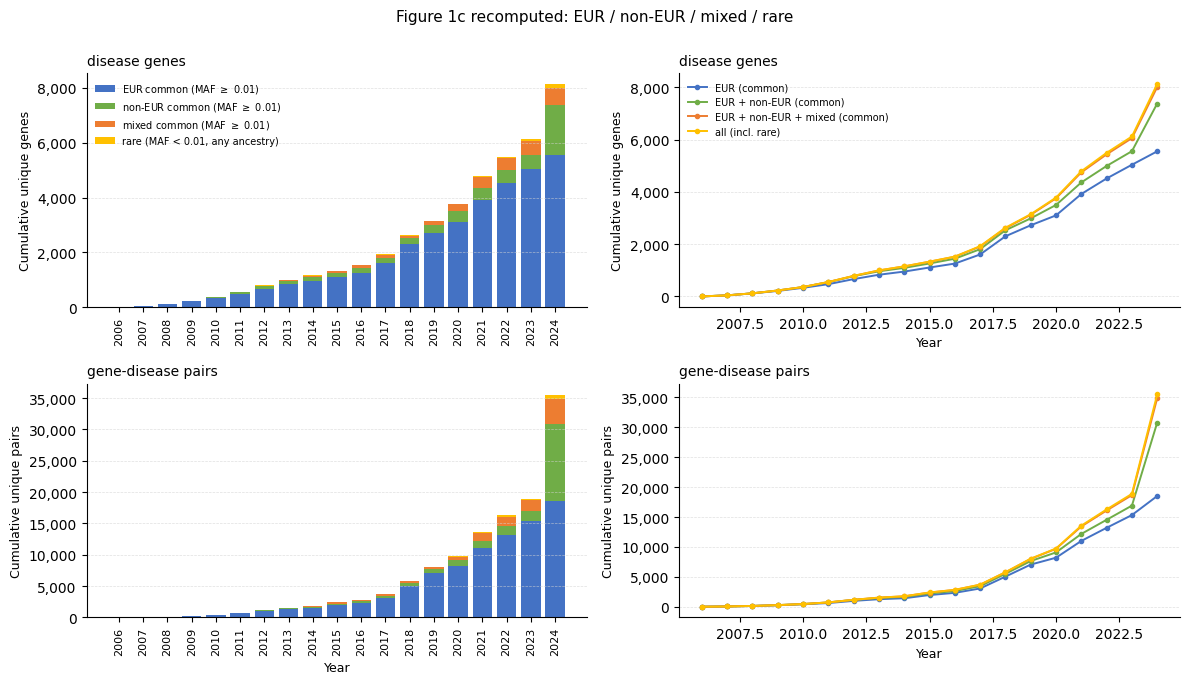

In [25]:
plot_metrics(
    fig1c_nested,
    [("disease genes", "Cumulative unique genes"), ("gene-disease pairs", "Cumulative unique pairs")],
    "Figure 1c recomputed: EUR / non-EUR / mixed / rare",
)

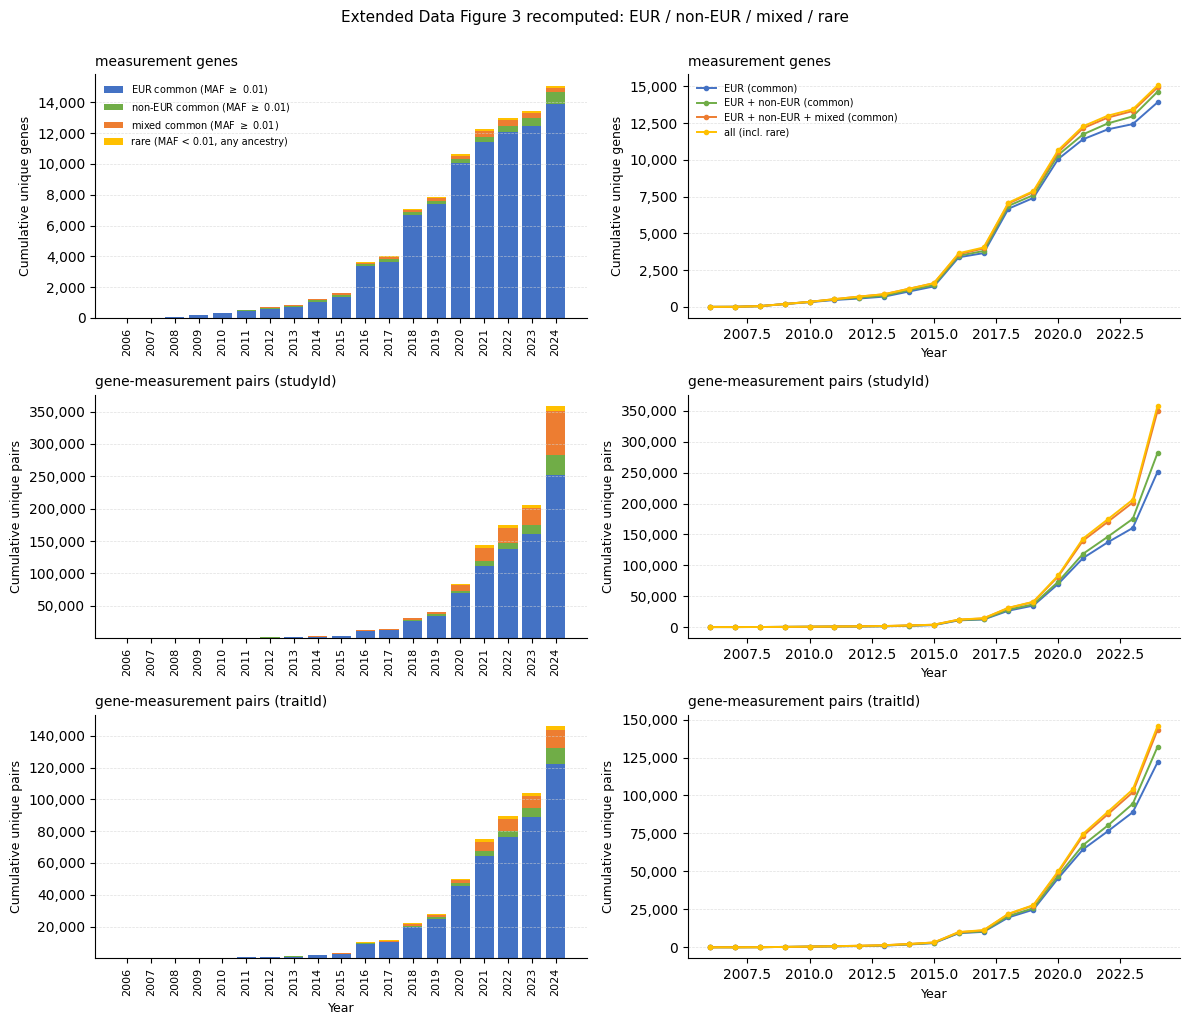

In [26]:
plot_metrics(
    ed3_nested,
    [
        ("measurement genes", "Cumulative unique genes"),
        ("gene-measurement pairs (studyId)", "Cumulative unique pairs"),
        ("gene-measurement pairs (traitId)", "Cumulative unique pairs"),
    ],
    "Extended Data Figure 3 recomputed: EUR / non-EUR / mixed / rare",
)

## 5. Headline numbers for the response

The nested tiers at 2024 give the sentence-level numbers: the total, the part reachable from
$\geq 90\%$ European studies with common variants, and what each subsequent label adds.

In [27]:
def headline(nested: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Final-year tier totals and increments for one metric.

    Args:
        nested: output of `nested_tiers`.
        metric: metric to extract.

    Returns:
        pandas.DataFrame: one row per tier with cumulative total, increment, and its share
        of the final total.
    """
    end = nested[(nested["metric"] == metric) & (nested["year"] == MAX_YEAR)].sort_values("tier_index")
    total = end["cumulative"].max()
    out = end[["metric", "tier", "tier_index", "cumulative"]].copy()
    out["increment"] = out["cumulative"].diff().fillna(out["cumulative"])
    out["increment_pct_of_total"] = 100 * out["increment"] / total
    out["cumulative_pct_of_total"] = 100 * out["cumulative"] / total
    return out


headline_table = pd.concat(
    [headline(fig1c_nested, m) for m in fig1c_nested["metric"].unique()]
    + [headline(ed3_nested, m) for m in ed3_nested["metric"].unique()],
    ignore_index=True,
)
headline_table

,metric,tier,tier_index,cumulative,increment,increment_pct_of_total,cumulative_pct_of_total
0,disease genes,EUR (common),1,5552,5552.0,68.298684,68.298684
1,disease genes,EUR + non-EUR (common),2,7381,1829.0,22.499692,90.798376
2,disease genes,EUR + non-EUR + mixed (common),3,8014,633.0,7.786936,98.585312
3,disease genes,all (incl. rare),4,8129,115.0,1.414688,100.000000
4,gene-disease pairs,EUR (common),1,18521,18521.0,52.120445,52.120445
5,gene-disease pairs,EUR + non-EUR (common),2,30806,12285.0,34.571549,86.691994
6,gene-disease pairs,EUR + non-EUR + mixed (common),3,34905,4099.0,11.535106,98.227100
7,gene-disease pairs,all (incl. rare),4,35535,630.0,1.772900,100.000000
8,measurement genes,EUR (common),1,13914,13914.0,92.384304,92.384304
9,measurement genes,EUR + non-EUR (common),2,14637,723.0,4.800478,97.184782


In [28]:
# Old vs new decomposition of the "~30% non-EUR" claim, for disease genes.
genes_new = fig1c_attribution[fig1c_attribution["metric"] == "disease genes"]
genes_old = fig1c_attribution[fig1c_attribution["metric"] == "disease genes (old scheme)"]

print("OLD binary scheme (EUR = >=90% NFE, non-EUR = everything else)")
print(genes_old[["stratum", "reachable", "reachable_pct", "exclusive", "exclusive_pct"]].to_string(index=False))
print()
print("NEW scheme (EUR / mixed / non-EUR / unknown)")
print(genes_new[["stratum", "reachable", "reachable_pct", "exclusive", "exclusive_pct"]].to_string(index=False))

OLD binary scheme (EUR = >=90% NFE, non-EUR = everything else)
            stratum  reachable  reachable_pct  exclusive  exclusive_pct
    EUR(old) common       5545      68.212572       1465      18.021897
      EUR(old) rare        221       2.718662         26       0.319843
non-EUR(old) common       6508      80.059048       2381      29.290196
  non-EUR(old) rare        507       6.236930         71       0.873416
              total       8129     100.000000       3943      48.505351

NEW scheme (EUR / mixed / non-EUR / unknown)
       stratum  reachable  reachable_pct  exclusive  exclusive_pct
    EUR common       5552      68.298684       1474      18.132612
      EUR rare        221       2.718662         27       0.332144
  mixed common       4168      51.273219        615       7.565506
    mixed rare        295       3.628983         22       0.270636
non-EUR common       4972      61.163735       1415      17.406815
  non-EUR rare        236       2.903186         49      

In [29]:
# Per-year first-discovery share by ancestry class (common variants), diseases.
share = (
    fig1c_marginal[(fig1c_marginal["metric"] == "disease genes") & (fig1c_marginal["freqClass"] == "common")]
    .pivot_table(index="year", columns="ancestryClass", values="count")
    .fillna(0)
)
share_pct = 100 * share.div(share.sum(axis=1), axis=0)
share_pct.round(1)

ancestryClass,EUR,mixed,non-EUR
year,,,
2006,100.0,0.0,0.0
2007,100.0,0.0,0.0
2008,96.2,0.0,3.8
2009,77.5,0.0,22.5
2010,79.3,1.3,19.3
2011,67.8,3.4,28.8
2012,73.2,3.4,23.4
2013,58.6,29.5,11.9
2014,60.8,29.6,9.5


## 6. Write outputs

In [30]:
outputs = {
    f"fig1c_cumulative_discovery_nested{SUFFIX}.csv": fig1c_nested,
    f"fig1c_cumulative_discovery_marginal{SUFFIX}.csv": fig1c_marginal,
    f"fig1c_discovery_attribution{SUFFIX}.csv": fig1c_attribution,
    f"ed3_cumulative_discovery_nested{SUFFIX}.csv": ed3_nested,
    f"ed3_cumulative_discovery_marginal{SUFFIX}.csv": ed3_marginal,
    f"ed3_discovery_attribution{SUFFIX}.csv": ed3_attribution,
    f"ancestry_discovery_headline{SUFFIX}.csv": headline_table,
    f"study_ancestry_counts{SUFFIX}.csv": study_summary,
    f"ancestry_composition{SUFFIX}.csv": ancestry_composition,
}

for name, table in outputs.items():
    path = path_to_intermediate_data_folder + name
    table.to_csv(path, index=False)
    print(f"wrote {path}  ({len(table):,} rows)")

wrote ../../../data/intermediate_files/fig1c_cumulative_discovery_nested-r1.csv  (152 rows)
wrote ../../../data/intermediate_files/fig1c_cumulative_discovery_marginal-r1.csv  (228 rows)
wrote ../../../data/intermediate_files/fig1c_discovery_attribution-r1.csv  (24 rows)
wrote ../../../data/intermediate_files/ed3_cumulative_discovery_nested-r1.csv  (228 rows)
wrote ../../../data/intermediate_files/ed3_cumulative_discovery_marginal-r1.csv  (342 rows)
wrote ../../../data/intermediate_files/ed3_discovery_attribution-r1.csv  (26 rows)
wrote ../../../data/intermediate_files/ancestry_discovery_headline-r1.csv  (20 rows)
wrote ../../../data/intermediate_files/study_ancestry_counts-r1.csv  (12 rows)
wrote ../../../data/intermediate_files/ancestry_composition-r1.csv  (8 rows)


## Files written

All under `data/intermediate_files/`, all suffixed `-r1`:

| File                                                            | Use                                                        |
| --------------------------------------------------------------- | ---------------------------------------------------------- |
| `study_ancestry_classification-r1.csv`                          | per-study ancestry label lookup (reuse in other R1 work)    |
| `study_ancestry_counts-r1.csv`                                  | study counts per class, per study subset                    |
| `ancestry_composition-r1.csv`                                   | what the `non-EUR` and `mixed` classes are made of           |
| `list_of_prioritised_genes_per_CS_with_year_ancestry-r1.parquet` | row-level table, superset of the original `*_nfe_maf` one   |
| `l2g_diseases_full-r1.csv`                                      | Figure 1c replot input                                     |
| `l2g_measurements_full-r1.csv`                                  | Extended Data Figure 3 replot input                        |
| `fig1c_cumulative_discovery_nested-r1.csv`                      | Fig 1c stacked-bar tiers and layer heights, per year        |
| `fig1c_cumulative_discovery_marginal-r1.csv`                    | Fig 1c per-stratum curves, per year                         |
| `fig1c_discovery_attribution-r1.csv`                            | reachable / exclusive / first-discovery counts, old vs new  |
| `ed3_cumulative_discovery_nested-r1.csv`                        | ED Fig 3 tiers and layer heights, per year                  |
| `ed3_cumulative_discovery_marginal-r1.csv`                      | ED Fig 3 per-stratum curves, per year                       |
| `ed3_discovery_attribution-r1.csv`                              | ED Fig 3 reachable / exclusive / first-discovery counts      |
| `ancestry_discovery_headline-r1.csv`                            | final-year tier totals and increments for the response text |

Figure scripts in `chapters/03-manuscript-figures/` are deliberately left untouched.